In [5]:
#Part 1: Step 1: Create VCF File
#create test VCF file with variants information for variant analysis

vcf_content = """##fileformat=VCFv4.2
#CHROM	POS	ID	REF	ALT	QUAL	FILTER
chr1	10583	rs1	G	A	99	PASS
chr1	10611	rs2	C	T	85	PASS
chr1	10616	rs3	G	A	45	LowQual
chr1	10642	rs4	T	C	92	PASS
chr1	10654	rs5	A	G	76	PASS
chr2	20321	rs6	G	T	88	PASS
chr2	20345	rs7	C	A	35	LowQual
chr2	20401	rs8	T	G	97	PASS
chr2	20455	rs9	A	C	91	PASS
chr3	30521	rs10	C	T	65	PASS
chr3	30588	rs11	G	A	72	PASS
chr3	30610	rs12	T	C	28	LowQual
chr3	30675	rs13	A	G	95	PASS
chr4	40125	rs14	G	C	89	PASS
chr4	40201	rs15	C	T	93	PASS
"""

with open("variants.vcf", "w") as file:
    file.write(vcf_content)

print("VCF file created successfully!")

VCF file created successfully!


In [6]:
#Step 2: Read the VCF file
with open("variants.vcf", "r") as file:
    for line in file:
        print(line.strip())

# Example: chr1  10583  rs1  G  A  99  PASS
# At position 10,583 on chromosome 1, the reference base is G, 
# but an alternative A was observed, with quality 99 and a PASS filter.

##fileformat=VCFv4.2
#CHROM	POS	ID	REF	ALT	QUAL	FILTER
chr1	10583	rs1	G	A	99	PASS
chr1	10611	rs2	C	T	85	PASS
chr1	10616	rs3	G	A	45	LowQual
chr1	10642	rs4	T	C	92	PASS
chr1	10654	rs5	A	G	76	PASS
chr2	20321	rs6	G	T	88	PASS
chr2	20345	rs7	C	A	35	LowQual
chr2	20401	rs8	T	G	97	PASS
chr2	20455	rs9	A	C	91	PASS
chr3	30521	rs10	C	T	65	PASS
chr3	30588	rs11	G	A	72	PASS
chr3	30610	rs12	T	C	28	LowQual
chr3	30675	rs13	A	G	95	PASS
chr4	40125	rs14	G	C	89	PASS
chr4	40201	rs15	C	T	93	PASS


In [7]:
# Step 4: Load into pandas for actual analysis, you should get a dataframe 
#containing 15 variants

import pandas as pd

variants = pd.read_csv(
    "variants.vcf",
    sep="\t",
    comment="#",
    names=["CHROM", "POS", "ID", "REF", "ALT", "QUAL", "FILTER"]
)

variants
                                                                                            

,CHROM,POS,ID,REF,ALT,QUAL,FILTER
0,chr1,10583,rs1,G,A,99,PASS
1,chr1,10611,rs2,C,T,85,PASS
2,chr1,10616,rs3,G,A,45,LowQual
3,chr1,10642,rs4,T,C,92,PASS
4,chr1,10654,rs5,A,G,76,PASS
5,chr2,20321,rs6,G,T,88,PASS
6,chr2,20345,rs7,C,A,35,LowQual
7,chr2,20401,rs8,T,G,97,PASS
8,chr2,20455,rs9,A,C,91,PASS
9,chr3,30521,rs10,C,T,65,PASS


In [8]:
#Find how many variants in the dataset
variants.shape

# Result: 15 variants were detected in the practice dataset

(15, 7)

In [9]:
#Step 4: Explore the data
variants.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   CHROM   15 non-null     object
 1   POS     15 non-null     int64 
 2   ID      15 non-null     object
 3   REF     15 non-null     object
 4   ALT     15 non-null     object
 5   QUAL    15 non-null     int64 
 6   FILTER  15 non-null     object
dtypes: int64(2), object(5)
memory usage: 972.0+ bytes


In [10]:
#How many variants passed QC?
#How many failed?
variants["FILTER"].value_counts()

FILTER
PASS       12
LowQual     3
Name: count, dtype: int64

In [11]:
#Which chromosome contains the most variants?
variants["CHROM"].value_counts()

CHROM
chr1    5
chr2    4
chr3    4
chr4    2
Name: count, dtype: int64

In [12]:
#Step 5: Filter Variants
#remove the low-quality variants.
filtered_variants = variants[
    variants["FILTER"] == "PASS"
].copy()

filtered_variants

,CHROM,POS,ID,REF,ALT,QUAL,FILTER
0,chr1,10583,rs1,G,A,99,PASS
1,chr1,10611,rs2,C,T,85,PASS
3,chr1,10642,rs4,T,C,92,PASS
4,chr1,10654,rs5,A,G,76,PASS
5,chr2,20321,rs6,G,T,88,PASS
7,chr2,20401,rs8,T,G,97,PASS
8,chr2,20455,rs9,A,C,91,PASS
9,chr3,30521,rs10,C,T,65,PASS
10,chr3,30588,rs11,G,A,72,PASS
12,chr3,30675,rs13,A,G,95,PASS


In [13]:
# 15 variants -> FILTER -> PASS variants
print("Original variants:", len(variants))
print("High-quality variants:", len(filtered_variants))

#15 total variants
#12 PASS variants → 80%
#3 LowQual variants → 20%

Original variants: 15
High-quality variants: 12


In [14]:
# Part 2: Explore the variants
# Step 1: Q1. Which chromosomes contain the variants?

variants["CHROM"].value_counts().sort_index()

CHROM
chr1    5
chr2    4
chr3    4
chr4    2
Name: count, dtype: int64

In [15]:
# Step 2: Look at the variant quality
# The QUAL score is a measure associated with confidence in the variant call.
variants["QUAL"].describe()

count    15.000000
mean     76.666667
std      23.255312
min      28.000000
25%      68.500000
50%      88.000000
75%      92.500000
max      99.000000
Name: QUAL, dtype: float64

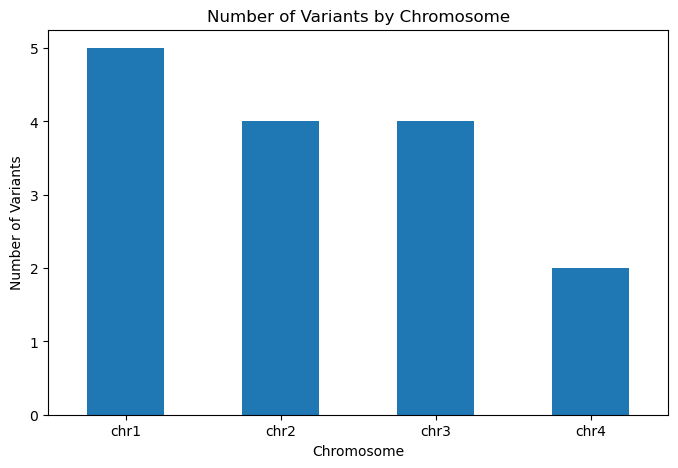

<Figure size 640x480 with 0 Axes>

In [16]:
#Step 3: Plot the number of variants on each chromosome

import matplotlib.pyplot as plt

chrom_counts = variants["CHROM"].value_counts().sort_index()

plt.figure(figsize=(8,5))
chrom_counts.plot(kind="bar")

plt.xlabel("Chromosome")
plt.ylabel("Number of Variants")
plt.title("Number of Variants by Chromosome")
plt.xticks(rotation=0)

plt.show()

plt.savefig(
    "figures/variants_by_chromosome.png",
    dpi=300,
    bbox_inches="tight"
)

In [17]:
#Result: VCF-> pandas -> 15 variants -> QC status -> chromosome distribution -> visualization

#Part 3 - Apply a quality filter
# Keep variants that have filter == Pass and Qual >= 70

high_quality = variants[
    (variants["FILTER"] == "PASS") &
    (variants["QUAL"] >= 70)
].copy()

high_quality

,CHROM,POS,ID,REF,ALT,QUAL,FILTER
0,chr1,10583,rs1,G,A,99,PASS
1,chr1,10611,rs2,C,T,85,PASS
3,chr1,10642,rs4,T,C,92,PASS
4,chr1,10654,rs5,A,G,76,PASS
5,chr2,20321,rs6,G,T,88,PASS
7,chr2,20401,rs8,T,G,97,PASS
8,chr2,20455,rs9,A,C,91,PASS
10,chr3,30588,rs11,G,A,72,PASS
12,chr3,30675,rs13,A,G,95,PASS
13,chr4,40125,rs14,G,C,89,PASS


In [18]:
print("Total variants:", len(variants))
print("PASS variants:", len(filtered_variants))
print("High-quality variants:", len(high_quality))

Total variants: 15
PASS variants: 12
High-quality variants: 11


In [19]:
#Now We will continue with two concepts- filtering criteria:
#1. Filter = Pass
#2. Filter = Pass and Qual >= 70

variants["CHROM"].value_counts().sort_index()

CHROM
chr1    5
chr2    4
chr3    4
chr4    2
Name: count, dtype: int64

In [20]:
variants["QUAL"].describe()

count    15.000000
mean     76.666667
std      23.255312
min      28.000000
25%      68.500000
50%      88.000000
75%      92.500000
max      99.000000
Name: QUAL, dtype: float64

In [21]:
high_quality = variants[
    (variants["FILTER"] == "PASS") &
    (variants["QUAL"] >= 70)
].copy()

print("Total variants:", len(variants))
print("PASS variants:", len(filtered_variants))
print("High-quality variants:", len(high_quality))

Total variants: 15
PASS variants: 12
High-quality variants: 11


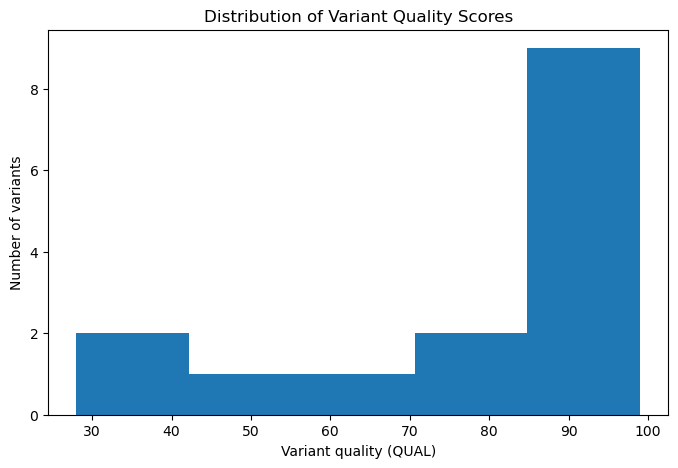

<Figure size 640x480 with 0 Axes>

In [22]:
#Visualize the quality scores

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(variants["QUAL"], bins=5)

plt.xlabel("Variant quality (QUAL)")
plt.ylabel("Number of variants")
plt.title("Distribution of Variant Quality Scores")


plt.show()

plt.savefig(
    "figures/quality_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

In [23]:
# Histogram shows that the distribution is concentrated towards the higher QUAL scores
# 1. A few variants have relatively low scores around 28-45
# 2. Some are in the middle range
# 3. Most are concentrated around 85-99

#This matches the statistics Median = 88 while min = 28 and max = 99
#visualization is telling the same story as your numerical summary.

# One important bioinformatics lesson:
#The histogram itself doesn't tell us that a variant is biologically "good" or "bad."
#QUAL is a variant-calling quality metric, and its precise interpretation depends 
#on the variant caller and workflow.




#Part 4: Identify the variant types

#create a new column ref->alt
variants["variant_type"] = (
    variants["REF"] + ">" + variants["ALT"]
)

variants[["CHROM", "POS", "REF", "ALT", "variant_type"]]

,CHROM,POS,REF,ALT,variant_type
0,chr1,10583,G,A,G>A
1,chr1,10611,C,T,C>T
2,chr1,10616,G,A,G>A
3,chr1,10642,T,C,T>C
4,chr1,10654,A,G,A>G
5,chr2,20321,G,T,G>T
6,chr2,20345,C,A,C>A
7,chr2,20401,T,G,T>G
8,chr2,20455,A,C,A>C
9,chr3,30521,C,T,C>T


In [24]:
#Step 2:
#Count the types
variants["variant_type"].value_counts()

variant_type
G>A    3
C>T    3
T>C    2
A>G    2
G>T    1
C>A    1
T>G    1
A>C    1
G>C    1
Name: count, dtype: int64

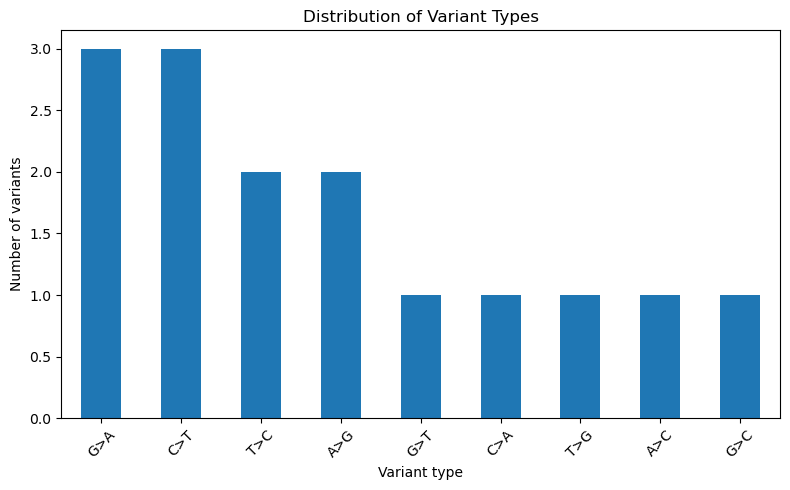

<Figure size 640x480 with 0 Axes>

In [25]:
#Step 3: Visualization

variant_counts = variants["variant_type"].value_counts()

plt.figure(figsize=(8, 5))

variant_counts.plot(kind="bar")

plt.xlabel("Variant type")
plt.ylabel("Number of variants")
plt.title("Distribution of Variant Types")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

plt.savefig(
    "figures/variant_types.png",
    dpi=300,
    bbox_inches="tight"
)

#Result: VCF-> Variant Identification -> Variant Classification -> Variant-type Distribution


In [26]:
#Part 5: Create our final high quality dataset
#Filtering Rule Pass + Qual greater than and equal to 70

high_quality = variants[
    (variants["FILTER"] == "PASS") &
    (variants["QUAL"] >= 70)
].copy()

print("Total variants:", len(variants))
print("PASS variants:", len(filtered_variants))
print("High-quality variants:", len(high_quality))

Total variants: 15
PASS variants: 12
High-quality variants: 11


In [27]:
high_quality

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,variant_type
0,chr1,10583,rs1,G,A,99,PASS,G>A
1,chr1,10611,rs2,C,T,85,PASS,C>T
3,chr1,10642,rs4,T,C,92,PASS,T>C
4,chr1,10654,rs5,A,G,76,PASS,A>G
5,chr2,20321,rs6,G,T,88,PASS,G>T
7,chr2,20401,rs8,T,G,97,PASS,T>G
8,chr2,20455,rs9,A,C,91,PASS,A>C
10,chr3,30588,rs11,G,A,72,PASS,G>A
12,chr3,30675,rs13,A,G,95,PASS,A>G
13,chr4,40125,rs14,G,C,89,PASS,G>C


In [28]:
# Export the results
high_quality.to_csv(
    "filtered_variants.csv",
    index=False
)

print("Filtered variants saved successfully!")

Filtered variants saved successfully!


In [29]:
# Part 7: Create a project summary
summary = {
    "Total variants": len(variants),
    "PASS variants": len(filtered_variants),
    "High-quality variants": len(high_quality),
    "Mean QUAL": variants["QUAL"].mean(),
    "Median QUAL": variants["QUAL"].median(),
    "Minimum QUAL": variants["QUAL"].min(),
    "Maximum QUAL": variants["QUAL"].max()
}

summary

{'Total variants': 15,
 'PASS variants': 12,
 'High-quality variants': 11,
 'Mean QUAL': np.float64(76.66666666666667),
 'Median QUAL': np.float64(88.0),
 'Minimum QUAL': np.int64(28),
 'Maximum QUAL': np.int64(99)}

In [30]:
#Part 8: Biological Interpretation:
#The dataset contained 15 candidate variants. Twelve variants were marked PASS, 
#while three were classified as LowQual. Applying an additional QUAL 
#threshold of ≥70 together with the PASS filter retained 10 variants for 
#downstream analysis. Variant quality scores ranged from 28 to 99, with a 
#median of 88. The quality distribution was concentrated toward higher scores.



In [36]:
variant_counts



variant_type
G>A    3
C>T    3
T>C    2
A>G    2
G>T    1
C>A    1
T>G    1
A>C    1
G>C    1
Name: count, dtype: int64

In [37]:
high_quality = variants[
    (variants["FILTER"] == "PASS") &
    (variants["QUAL"] >= 70)
].copy()

print("Total variants:", len(variants))
print("PASS variants:", len(filtered_variants))
print("High-quality variants:", len(high_quality))



Total variants: 15
PASS variants: 12
High-quality variants: 11


In [42]:
high_quality

Saved: filtered_variants.csv


In [43]:
high_quality.to_csv(
    "filtered_variants.csv",
    index=False
)

print("Saved:", "filtered_variants.csv")


{'Total variants': 15,
 'PASS variants': 12,
 'High-quality variants': 11,
 'Mean QUAL': np.float64(76.66666666666667),
 'Median QUAL': np.float64(88.0),
 'Minimum QUAL': np.int64(28),
 'Maximum QUAL': np.int64(99)}

In [ ]:

summary = {
    "Total variants": len(variants),
    "PASS variants": len(filtered_variants),
    "High-quality variants": len(high_quality),
    "Mean QUAL": variants["QUAL"].mean(),
    "Median QUAL": variants["QUAL"].median(),
    "Minimum QUAL": variants["QUAL"].min(),
    "Maximum QUAL": variants["QUAL"].max()
}

summary